<a href="https://colab.research.google.com/github/dayquispe/machine-learning-pipeline-clientes/blob/main/Regress%C3%A3o_Regress%C3%A3o_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CP1 - Machine Learning: Modelos de Classificação e Regressão

### Integrantes:
- Gustavo Moreno Coelho - RM 556289
- Gustavo Atanazio - RM 559098
- Dayana Quispe - RM 558023
- Matheus Alves - RM 555177
- Nicolas Aquino - RM 556617

In [1]:
# Upload e Leitura
import pandas as pd
url = 'https://raw.githubusercontent.com/dayquispe/machine-learning-pipeline-clientes/main/customer_purchase_data.csv'
df = pd.read_csv(url)
print(df.head())

   Age  Gender   AnnualIncome  NumberOfPurchases  ProductCategory  \
0   40       1   66120.267939                  8                0   
1   20       1   23579.773583                  4                2   
2   27       1  127821.306432                 11                2   
3   24       1  137798.623120                 19                3   
4   31       1   99300.964220                 19                1   

   TimeSpentOnWebsite  LoyaltyProgram  DiscountsAvailed  PurchaseStatus  
0           30.568601               0                 5               1  
1           38.240097               0                 5               0  
2           31.633212               1                 0               1  
3           46.167059               0                 4               1  
4           19.823592               0                 0               1  


In [2]:
# =========================
# ANÁLISE INICIAL DOS DADOS
# =========================

print("Shape do dataset:", df.shape)
print("\nTipos de dados:")
print(df.dtypes)

print("\nValores nulos:")
print(df.isnull().sum())

Shape do dataset: (1500, 9)

Tipos de dados:
Age                     int64
Gender                  int64
AnnualIncome          float64
NumberOfPurchases       int64
ProductCategory         int64
TimeSpentOnWebsite    float64
LoyaltyProgram          int64
DiscountsAvailed        int64
PurchaseStatus          int64
dtype: object

Valores nulos:
Age                   0
Gender                0
AnnualIncome          0
NumberOfPurchases     0
ProductCategory       0
TimeSpentOnWebsite    0
LoyaltyProgram        0
DiscountsAvailed      0
PurchaseStatus        0
dtype: int64


In [3]:
# 1. IMPORTS
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Parte 2 - Regressão

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# TARGET
X = df.drop(['PurchaseStatus', 'AnnualIncome', 'TimeSpentOnWebsite'], axis=1)
y = df['TimeSpentOnWebsite']

# Divisão
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Previsão
y_pred = model.predict(X_test)

# Métricas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Regressão Linear ---")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)


--- Regressão Linear ---
MAE: 14.871702382207513
MSE: 296.0917492589053
RMSE: 17.207316736170846
R²: -0.015444501248097042


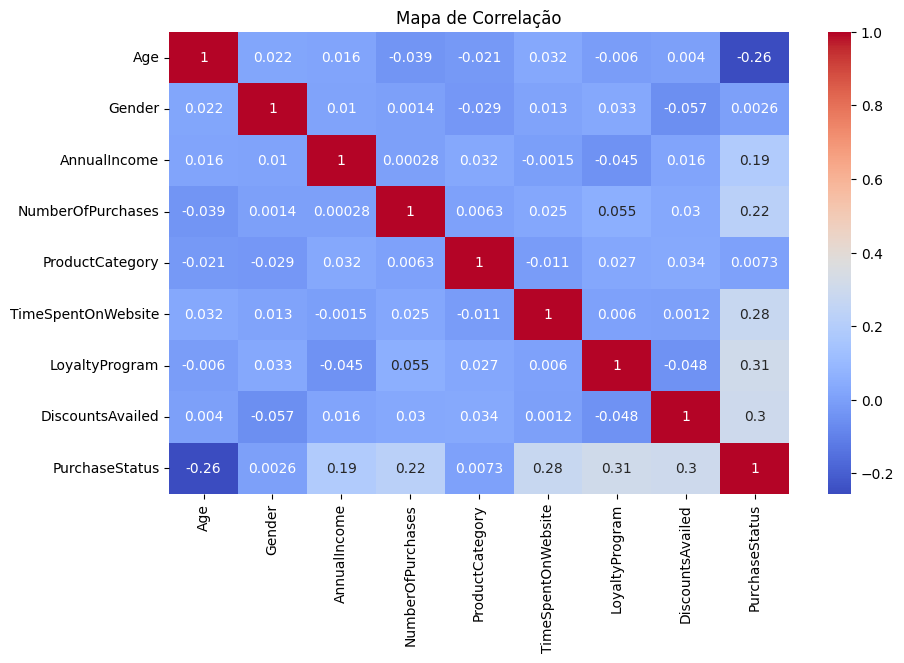

In [5]:
# Mapa de Correlação

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Mapa de Correlação")
plt.show()